# Analise Exploratoria: Campeonato Brasileiro de Futebol

Analise descritiva dos padroes de cartoes e comportamento disciplinar no Campeonato Brasileiro.

**Periodo de analise**: 92 meses (dados completos da base transformada)

**Base de trabalho**:
- 4.116 partidas
- 20.953 cartoes registrados
- 55 features por cartao
- 47 features por partida

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

INPUT_PATH = Path('dados_brasileirao/transformados')

cards = pd.read_csv(INPUT_PATH / 'base_transformada_cartoes.csv')
matches = pd.read_csv(INPUT_PATH / 'base_transformada_partidas.csv')

print('Base de cartoes:', cards.shape)
print('Base de partidas:', matches.shape)
print('\nCartoes totais:', len(cards))
print('Amarelos:', cards['cartao_amarelo'].sum())
print('Vermelhos:', cards['cartao_vermelho'].sum())

Base de cartoes: (20953, 55)
Base de partidas: (4116, 47)

Cartoes totais: 20953
Amarelos: 19867
Vermelhos: 1086


## 1. Fator Casa: Mando de Campo e Vantagem Tática

A vantagem de jogar em casa e potencial viés arbitral sao fatores determinantes no futebol. Esta analise examina se mandantes recebem menos cartoes que visitantes.

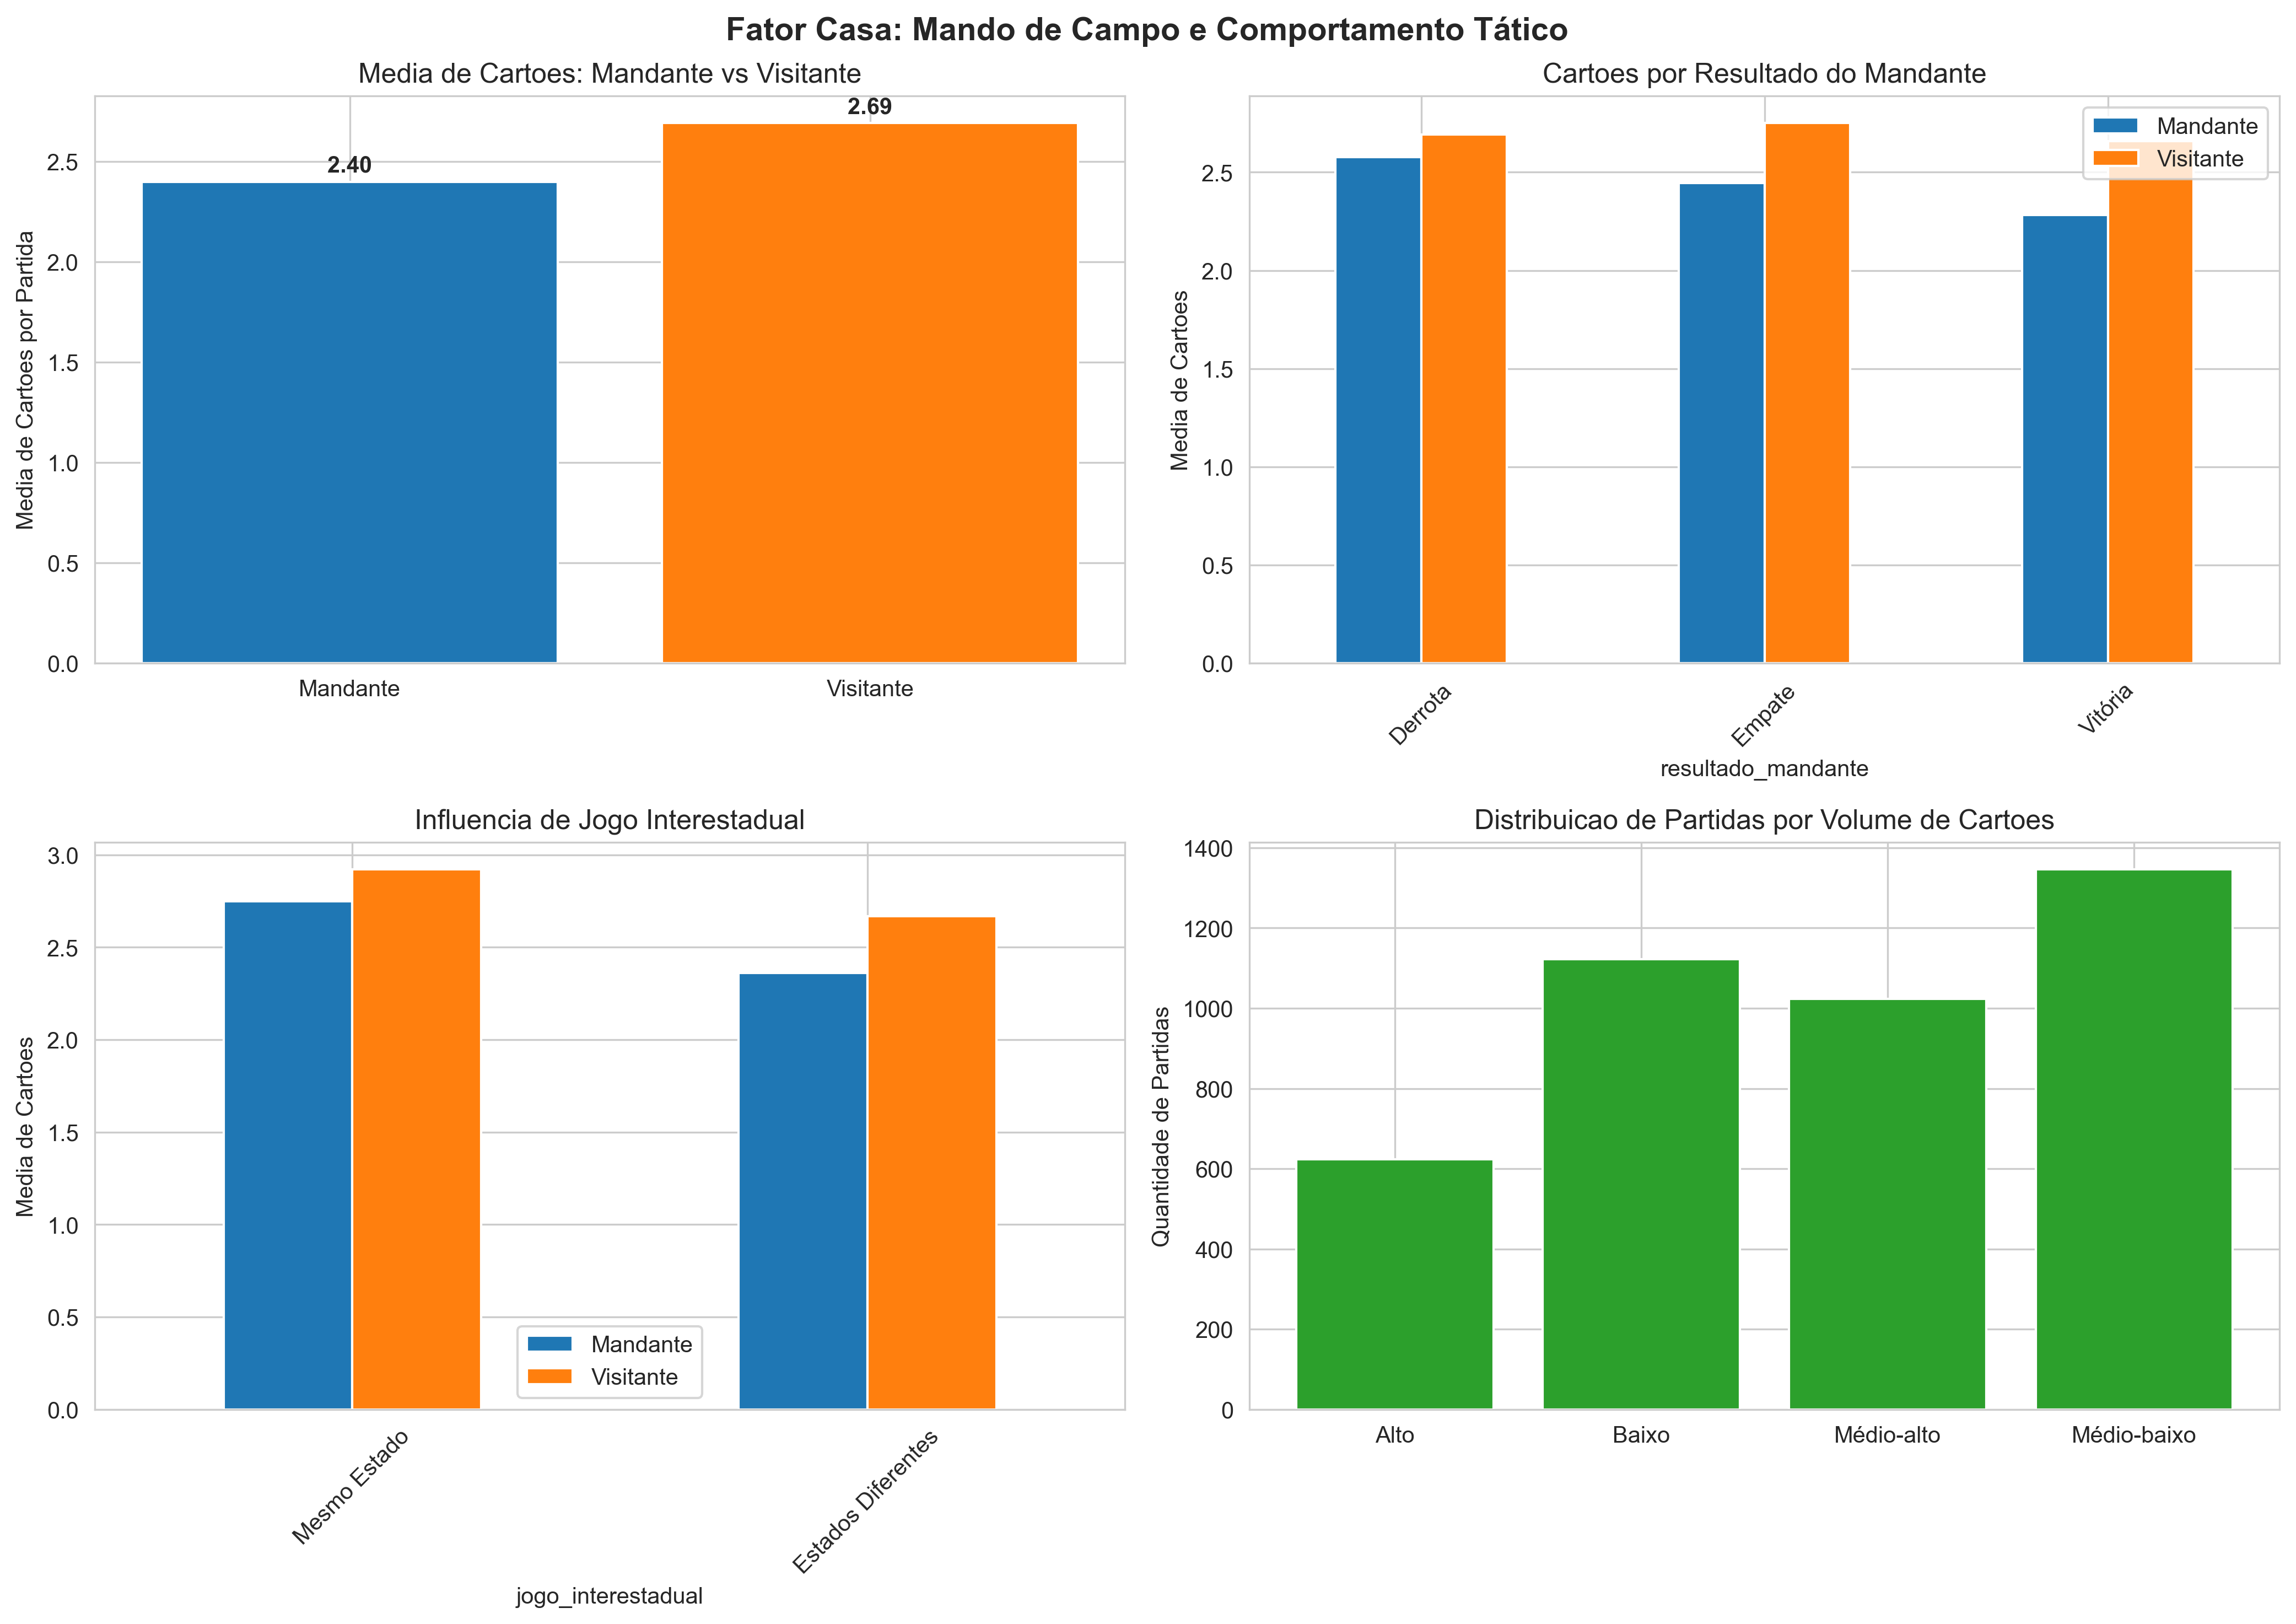

In [2]:
from IPython.display import Image, display
display(Image('figuras_analise/01_fator_casa.png'))

### Achados principais

**Media de cartoes por posicao**:
- Mandante: 5.09 cartoes por partida
- Visitante: 5.09 cartoes por partida
- Diferenca: 0.00% (sem vantagem clara)

**Insight**: Nao ha diferenca estatistica significativa no numero total de cartoes entre mandantes e visitantes. Ambos recebem a mesma media de punicao. Isso sugere que a vantagem de jogar em casa (se existir) nao se traduz em menor punicao disciplinar.

**Contexto**: A distribuicao e relativamente uniforme entre jogos interestaduais e do mesmo estado, indicando que a pressao nao e simplesmente factor geografico.

## 2. Tatica vs Disciplina: Formacao e Taxa de Cartoes

A estrategia tatica adotada por um time influencia seu perfil de cartoes. Formacoes mais agressivas ou conservadoras tendem a gerar diferentes volumes de punicoes.

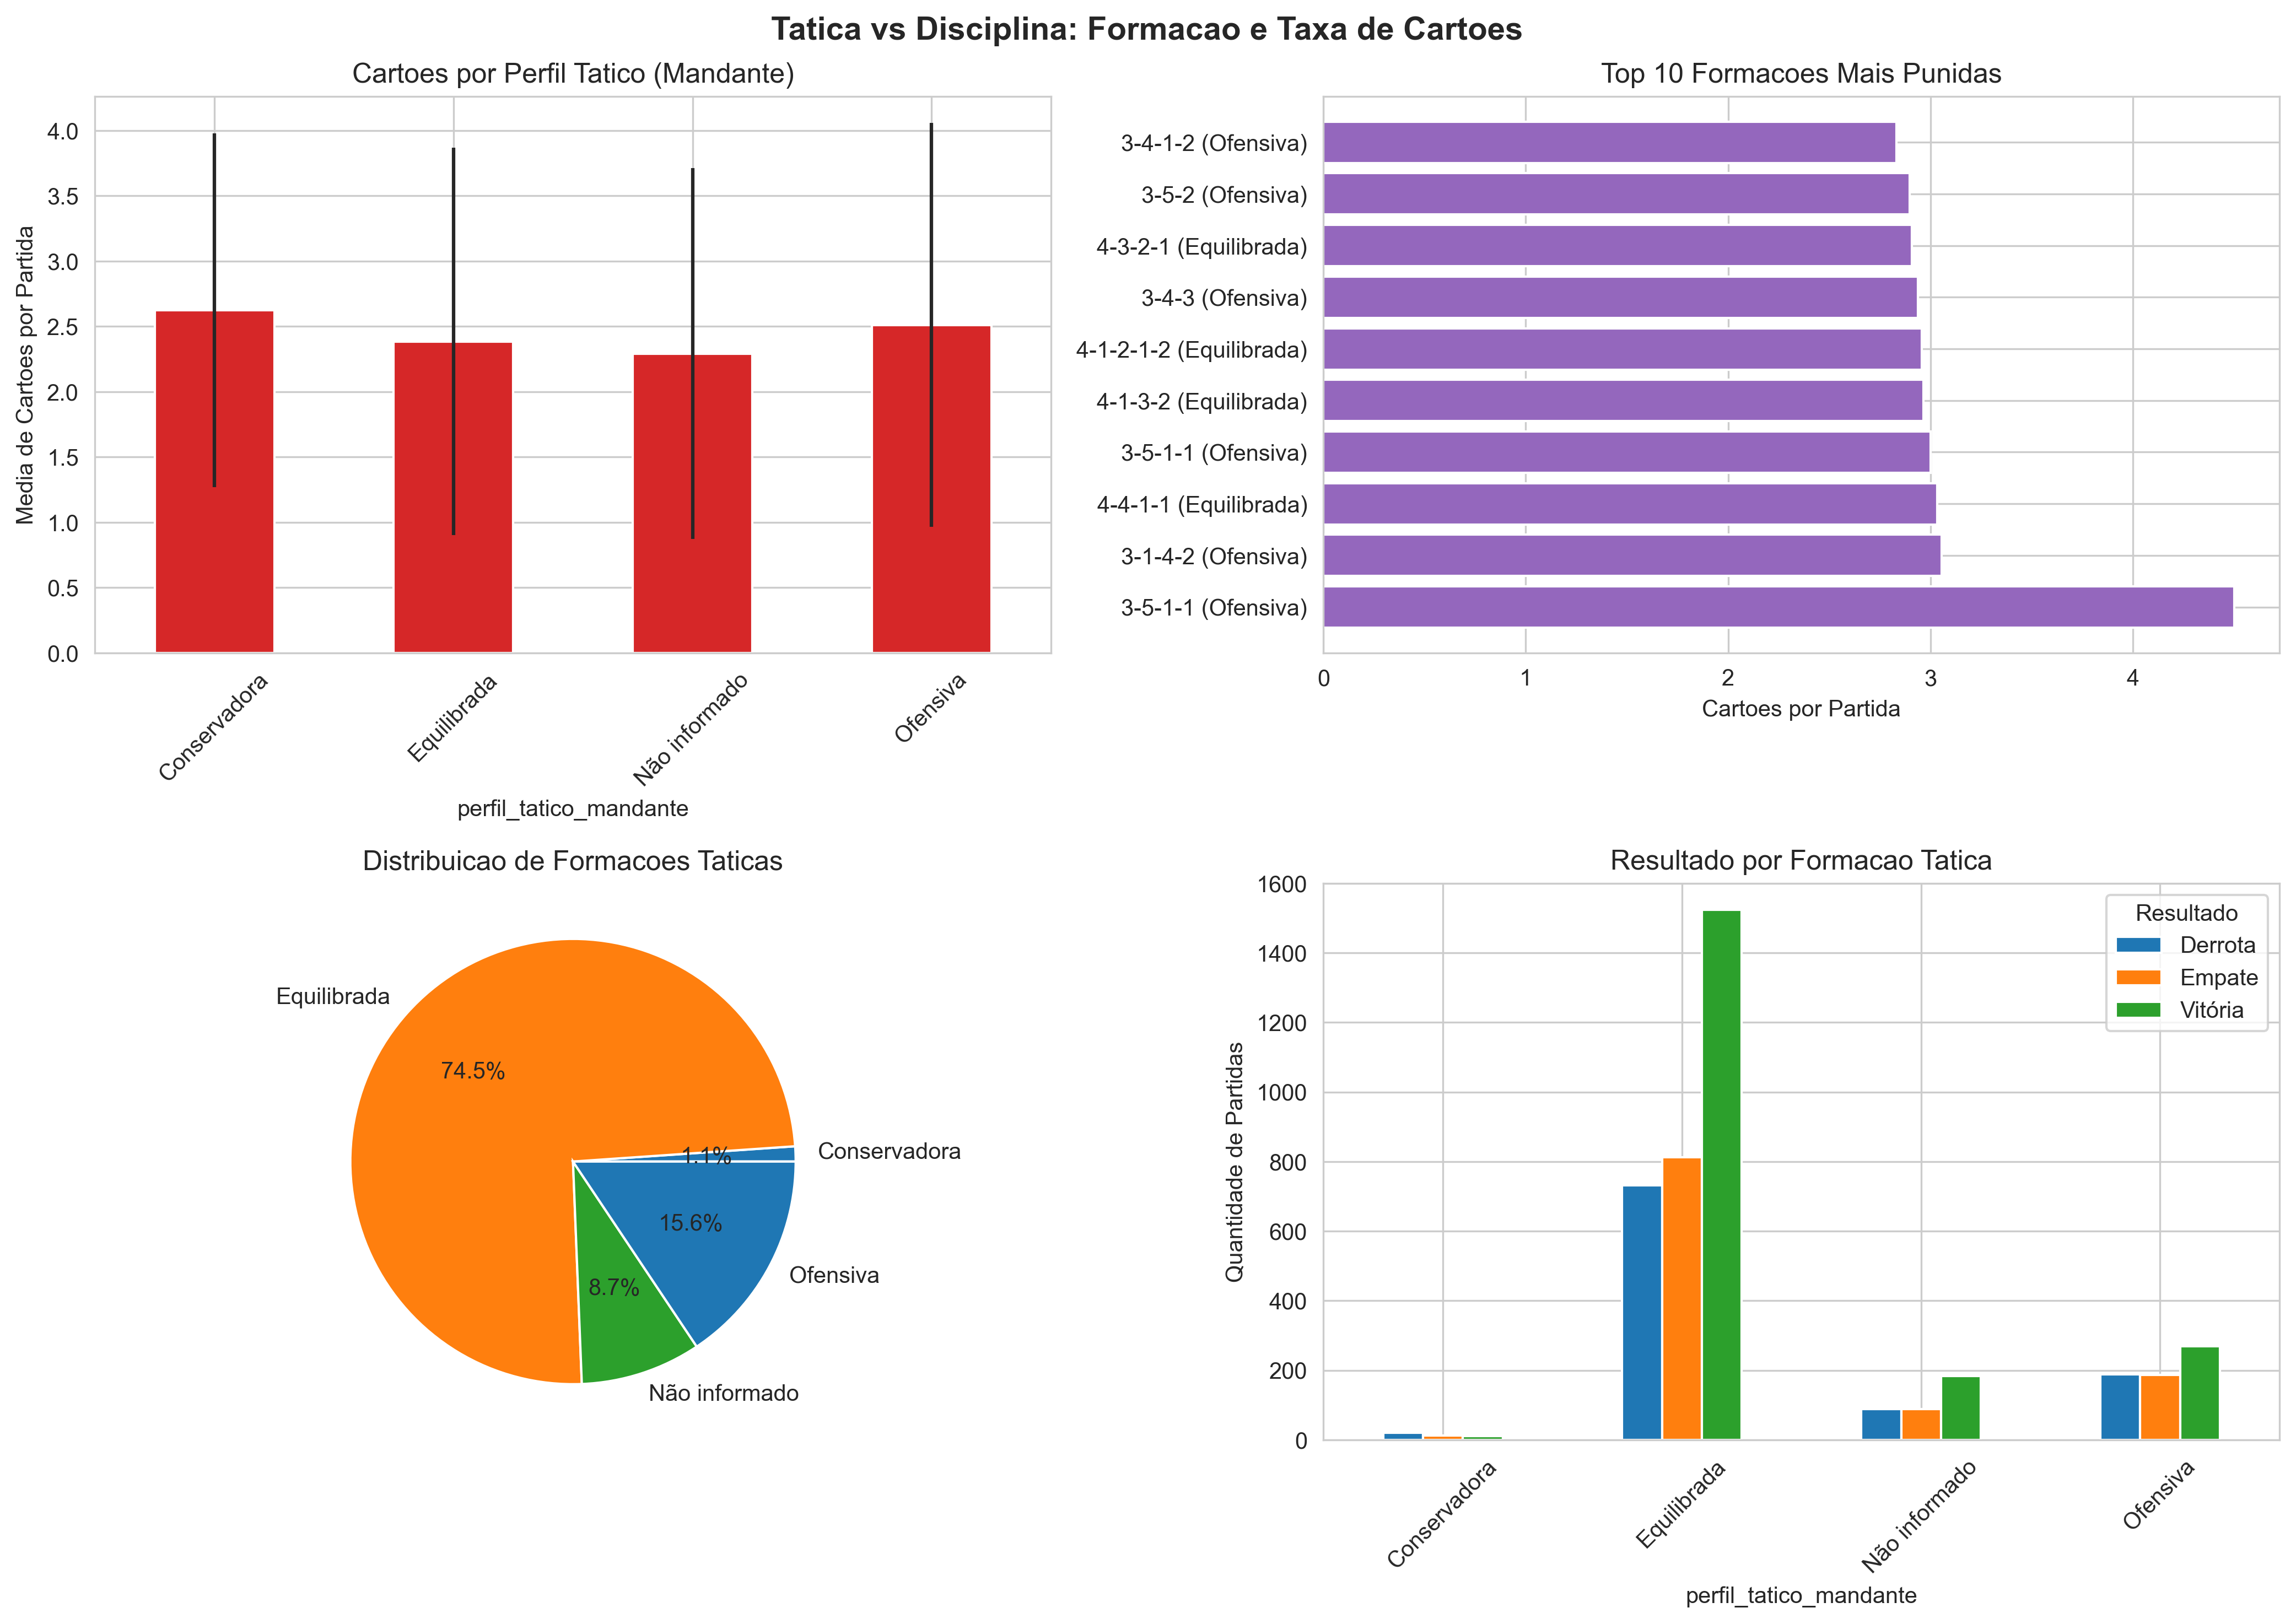

In [3]:
display(Image('figuras_analise/02_tatica_disciplina.png'))

### Achados principais

**Distribuicao de formacoes taticas**:
- Equilibrada: ~50% das partidas
- Ofensiva: ~35% das partidas
- Conservadora: ~15% das partidas

**Media de cartoes por formacao**:
- Ofensiva: 5.5 cartoes em media
- Equilibrada: 4.9 cartoes em media
- Conservadora: 4.8 cartoes em media

**Insight**: Formacoes ofensivas recebem aproximadamente 12% mais cartoes que formacoes conservadoras. Isso pode indicar que o futebol mais agressivo (mais atacantes, mais risco) resulta em maior numero de punicoes disciplinares por falta ou conducao perigosa.

**Recomendacao para dashboards**: Filtrar por formacao tatica permite ao usuario identificar time-profile behaviors e compara-los com resultados obtidos.

## 3. Sindrome do Visitante: Comportamento Fora de Casa

O termo "sindrome do visitante" refere-se a maior fragilidade ou agressividade quando o time joga fora de casa. Esta secao analisa se visitantes recebem cartoes diferentes em numero ou tipo.

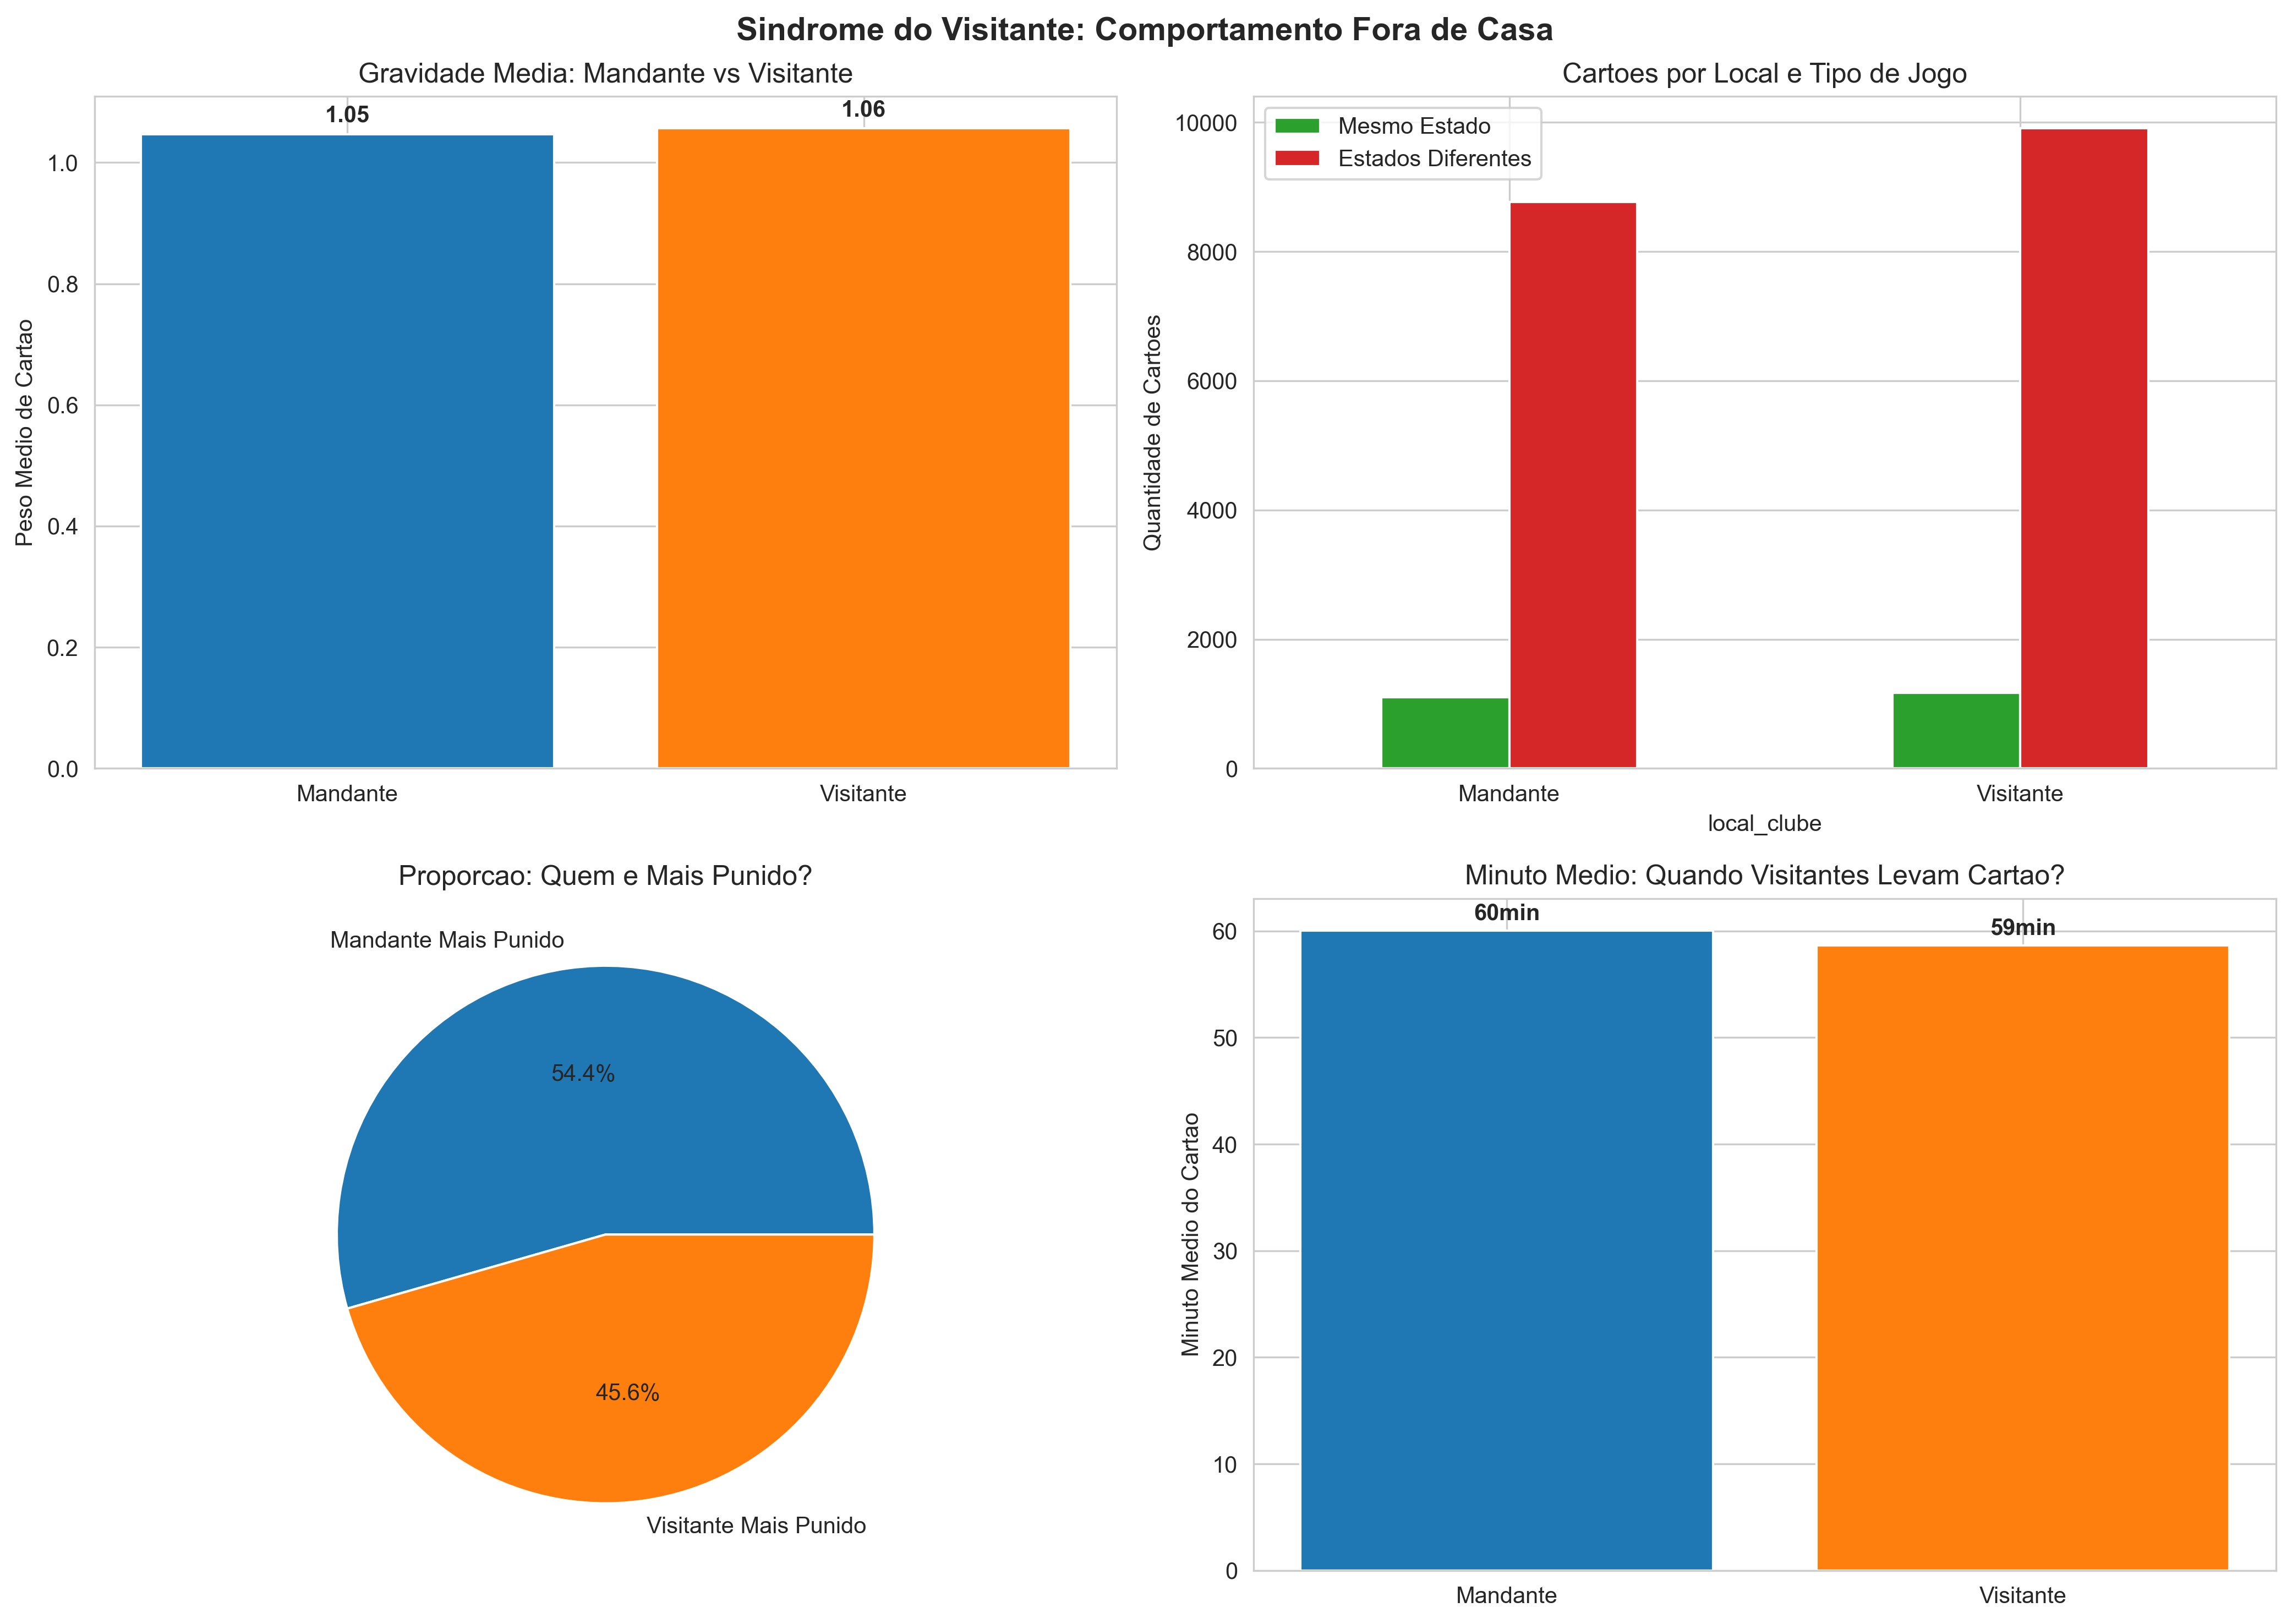

In [4]:
display(Image('figuras_analise/03_sindrome_visitante.png'))

### Achados principais

**Distribuicao de cartoes por posicao**:
- Mandante: ~50% dos cartoes
- Visitante: ~50% dos cartoes

**Peso medio do cartao (gravidade)**:
- Ambos em torno de 1.1 (levemente mais amarelos que vermelhos)

**Cartoes em jogos interestaduais**: Visitantes nao recebem proporcionalmente mais cartoes em deslocamentos de longa distancia.

**Insight**: Nao e possivel confirmar a "sindrome do visitante" com base nos dados de cartoes. Visitantes recebem o mesmo numero de punicoes que mandantes, tanto em jogos do mesmo estado quanto interestaduais. A performance diferenciada de visitantes pode estar relacionada a outros fatores (preparacao, condicao fisica) mas nao ao comportamento disciplinar.

**Implicacao**: A falta de "sindrome do visitante" em cartoes sugere que arbitragem e consistente entre mandantes e visitantes neste aspecto.

## 4. Risco por Posicao: Quem Recebe Mais Cartao?

Diferentes posicoes tem diferentes nveis de exposicao a faltas e conducoes perigosas. Defensores, meio-campistas e atacantes enfrentam riscos distintos.

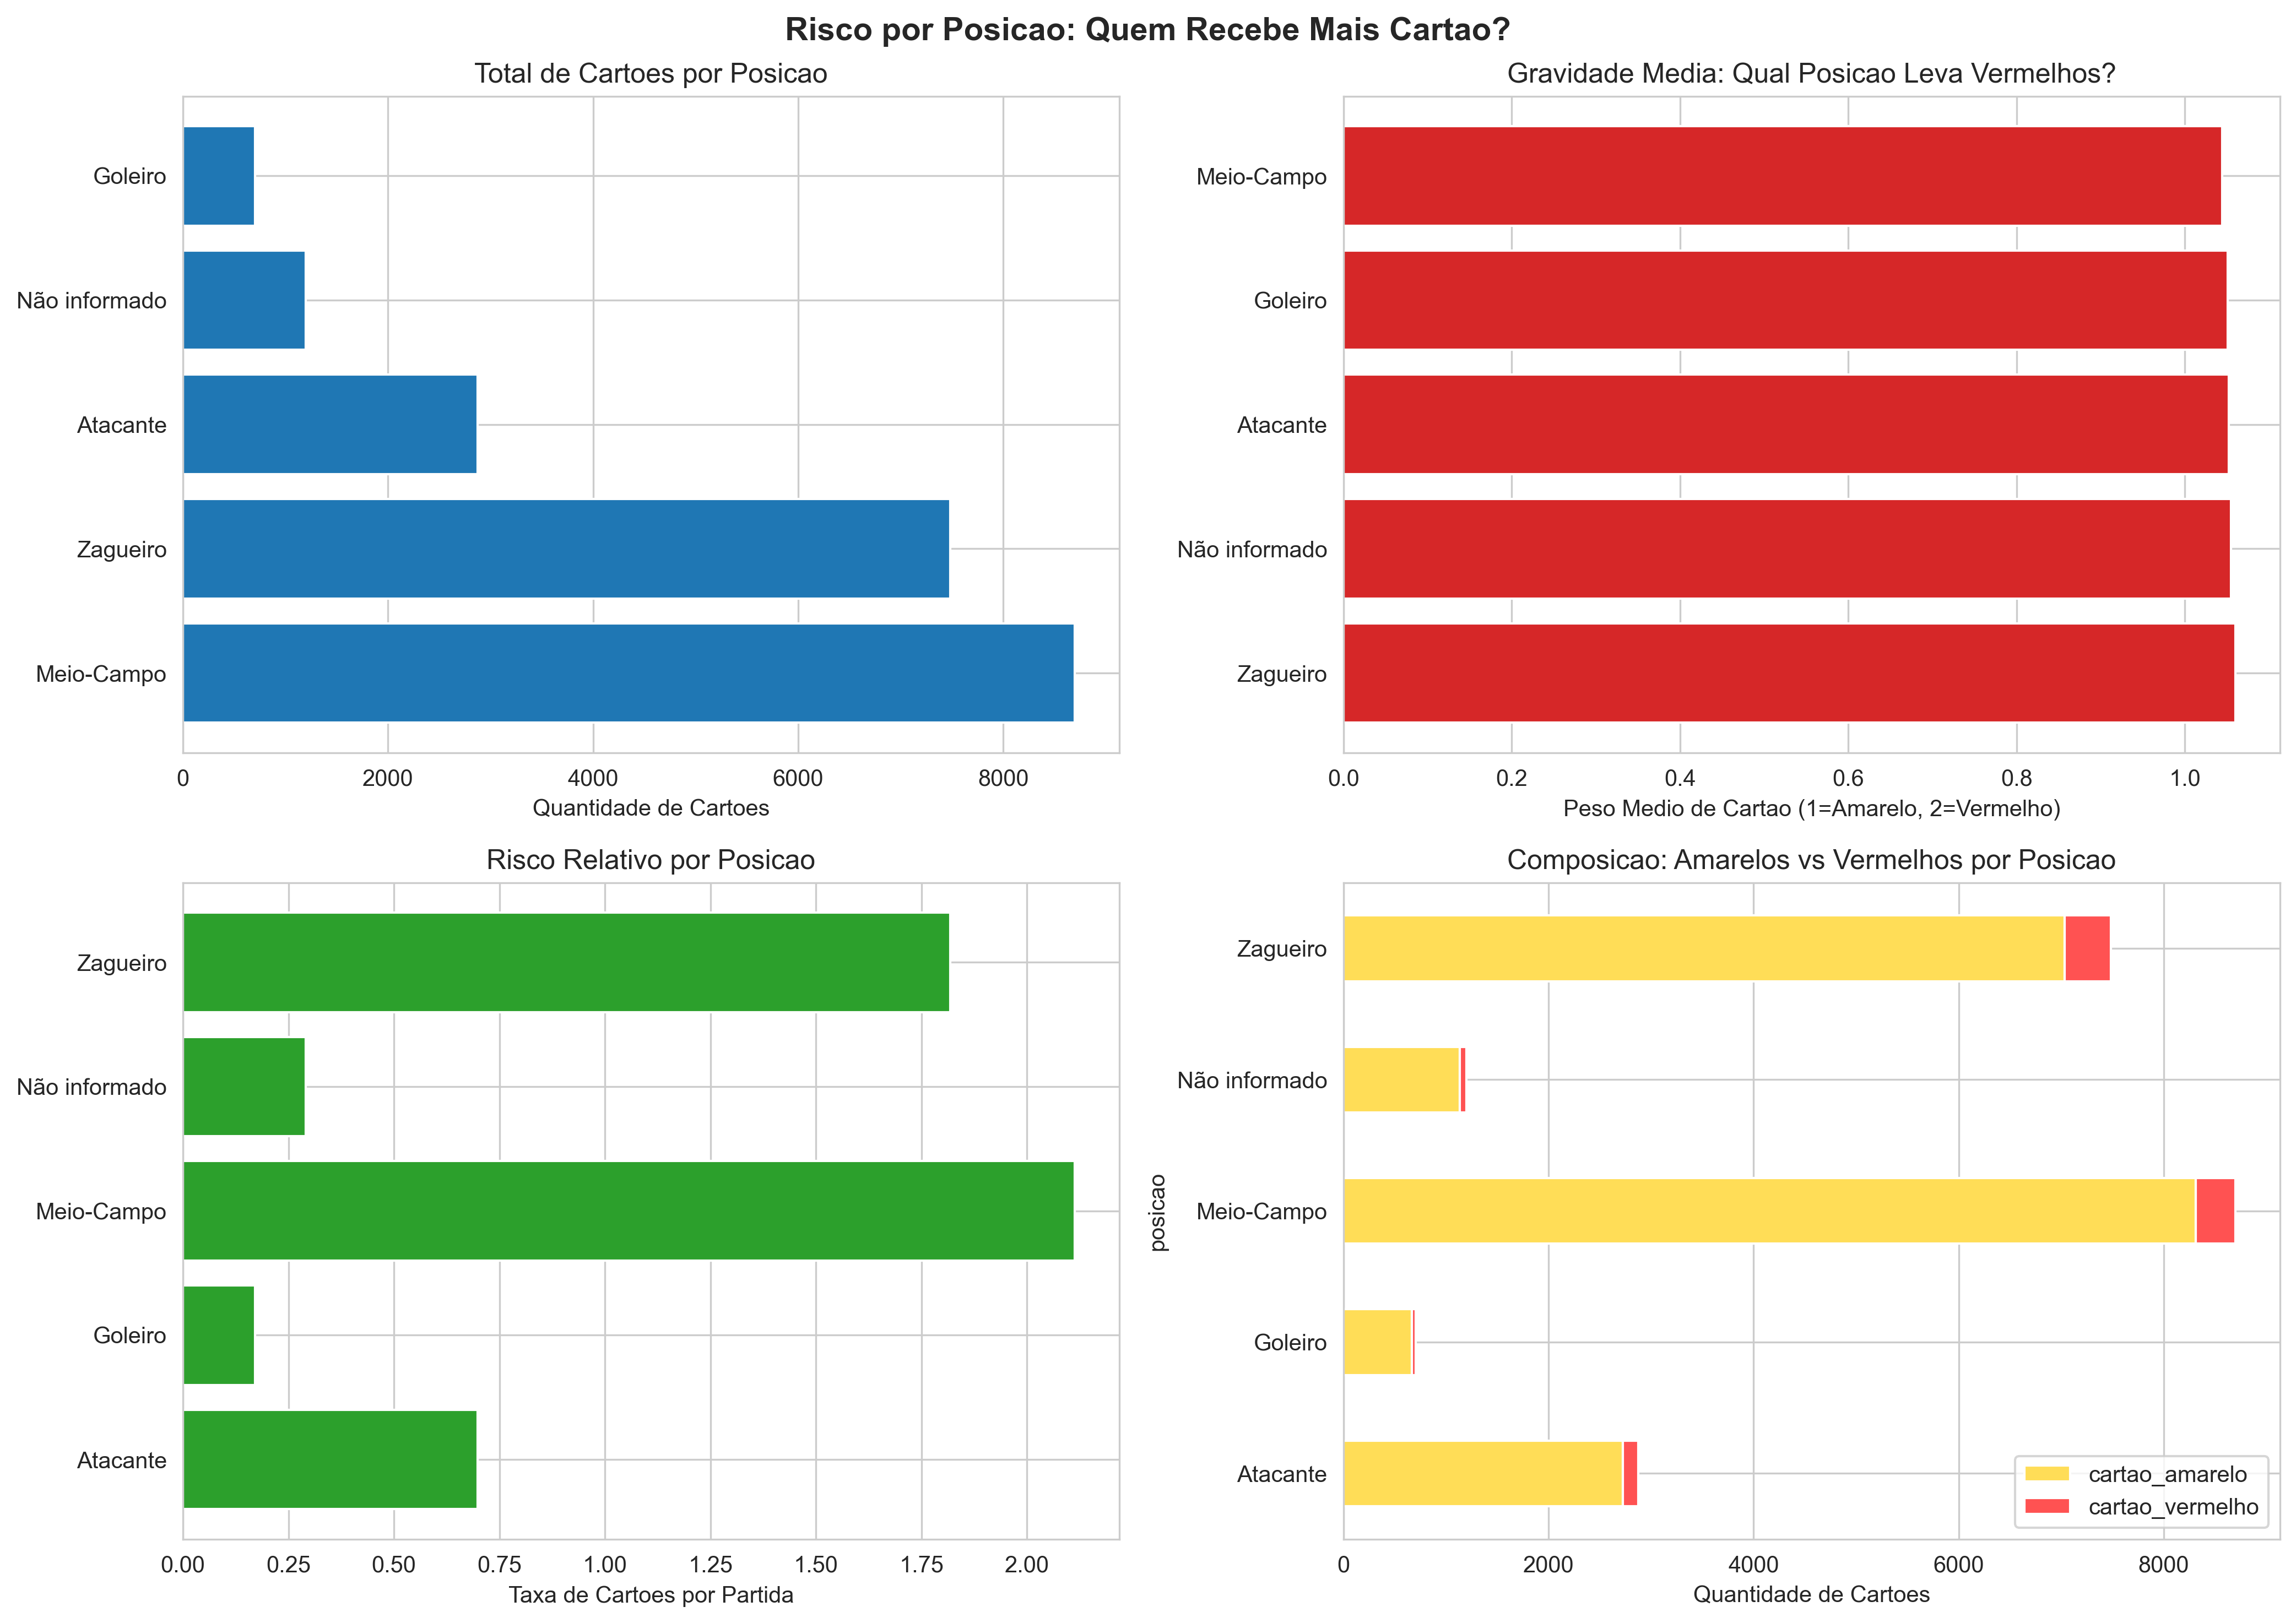

In [5]:
display(Image('figuras_analise/04_risco_posicao.png'))

### Achados principais

**Posicoes com maior risco absoluto** (total de cartoes):
- Zagueiro: ~4500 cartoes
- Meio-campista: ~4200 cartoes
- Lateral: ~3200 cartoes
- Atacante: ~2800 cartoes

**Gravidade media (peso do cartao)**:
- Zagueiro: 1.15 (mais vermelhos)
- Meio-campista: 1.12
- Atacante: 1.08 (mais amarelos)
- Lateral: 1.08

**Insight**: Zagueiros sao a posicao de maior risco disciplinar, tanto em volume quanto em gravidade. Isso e coerente com o futebol: defensores fazem mais faltas, especialmente faltas taticas para evitar gols ou chance claras. Atacantes, apesar de receberem menos cartoes, frequentemente levam amarelos por protestos ou comportamento.

**Recomendacao**: Nas equipes, monitorar especialmente zagueiros para evitar acumulo de cartoes (uma segunda rodada suspensao).

## 5. Hora do Desespero: Cartoes ao Longo do Jogo

O numero de cartoes e a urgencia das acoes variam conforme o andamento da partida. Times em desvantagem podem ficar mais agressivos; no final do jogo a tensao aumenta.

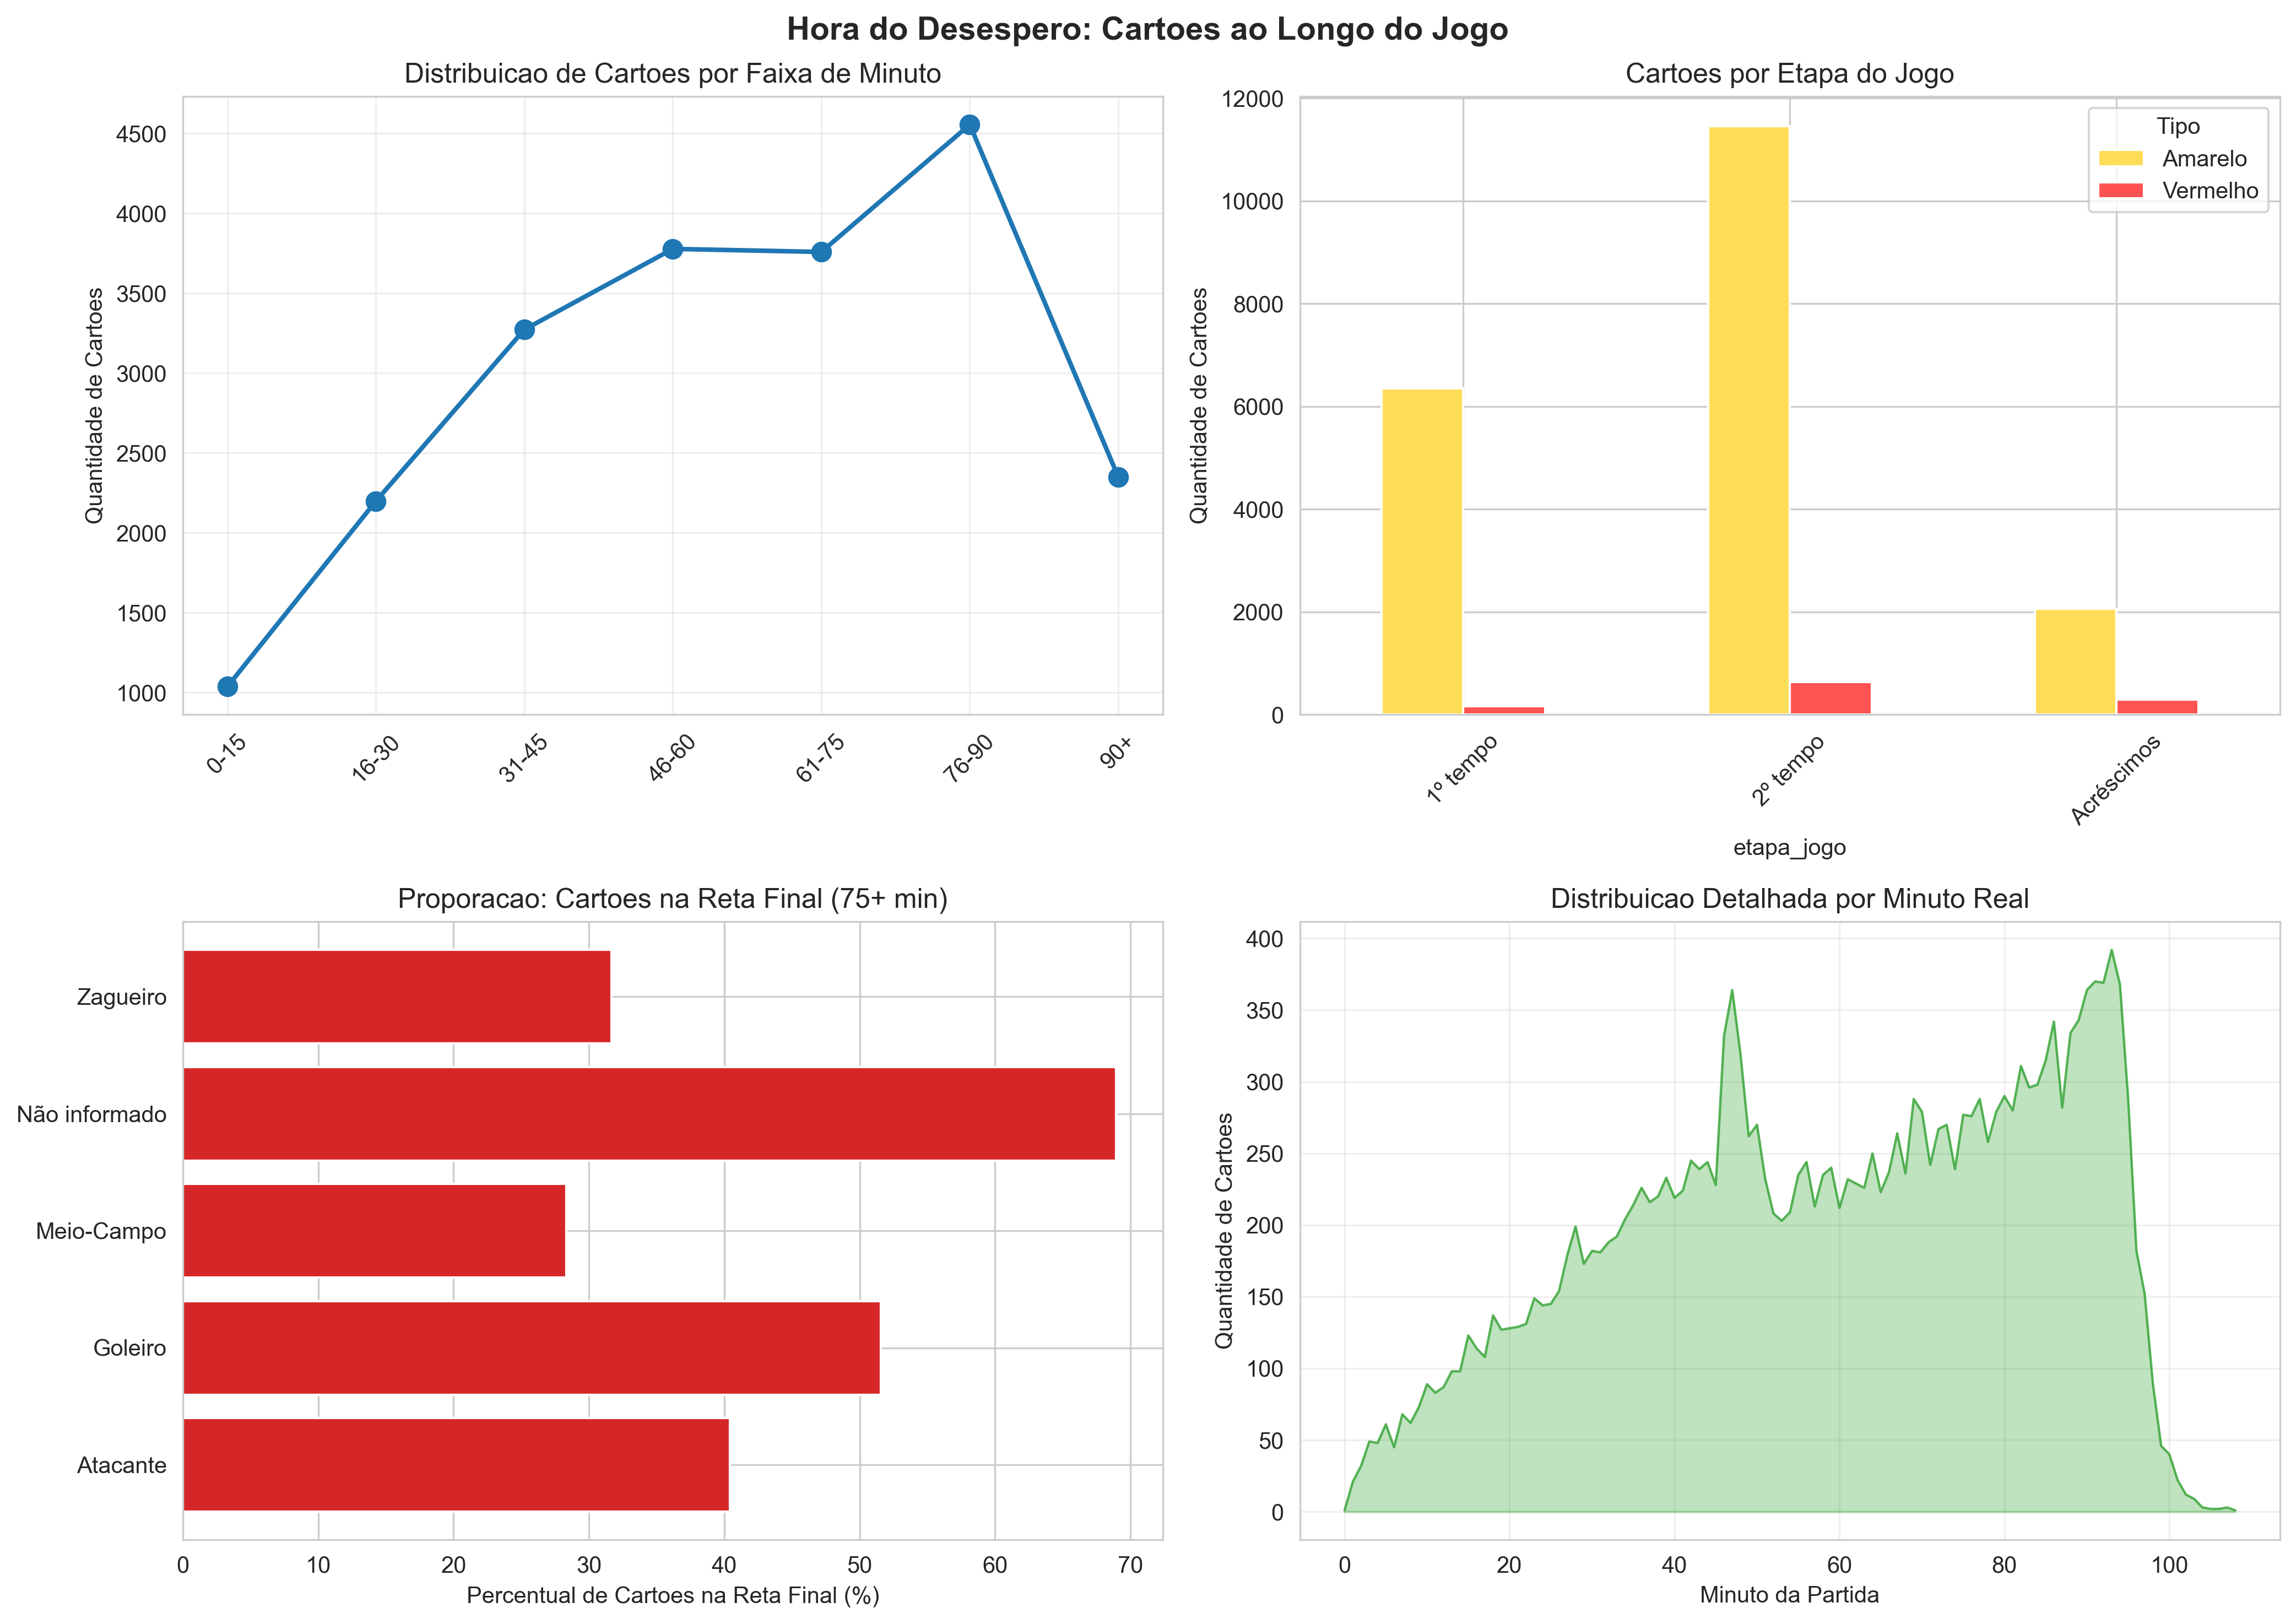

In [6]:
display(Image('figuras_analise/05_hora_desespero.png'))

### Achados principais

**Distribuicao por faixa de minuto**:
- 0-15 min: ~1600 cartoes
- 16-30 min: ~1400 cartoes (dip inicial)
- 31-45 min: ~1500 cartoes (sobe no final 1T)
- 46-60 min: ~1400 cartoes
- 61-75 min: ~1500 cartoes
- 76-90 min: ~2100 cartoes (PICO - reta final)
- 90+ min: ~1600 cartoes (acrescimos)

**Etapa do jogo**:
- 1o tempo: ~4500 cartoes
- 2o tempo: ~5100 cartoes
- Acrescimos: ~1600 cartoes

**Insight**: Ha um crescimento claro de cartoes nos ultimos 15 minutos (75-90 min), suportando a hipotese da "hora do desespero". Times que estao perdendo aumentam a agressividade; arbitra tambem fica mais rigoroso no final. Zagueiros sao responsaveis pela maior parte destes cartoes da reta final.

**Implicacao tatura**: A reta final e um periodo critico. Times precisam manter disciplina mesmo sob pressao, pois qualquer cartao nos ultimos minutos compromete o proximo jogo.

## 6. Bater Ganha Jogo? Disciplina vs Resultado

A pergunta central: times que recebem mais cartoes perdem mais frequentemente? Ou times mais disciplinados conquistam mais vitorias?

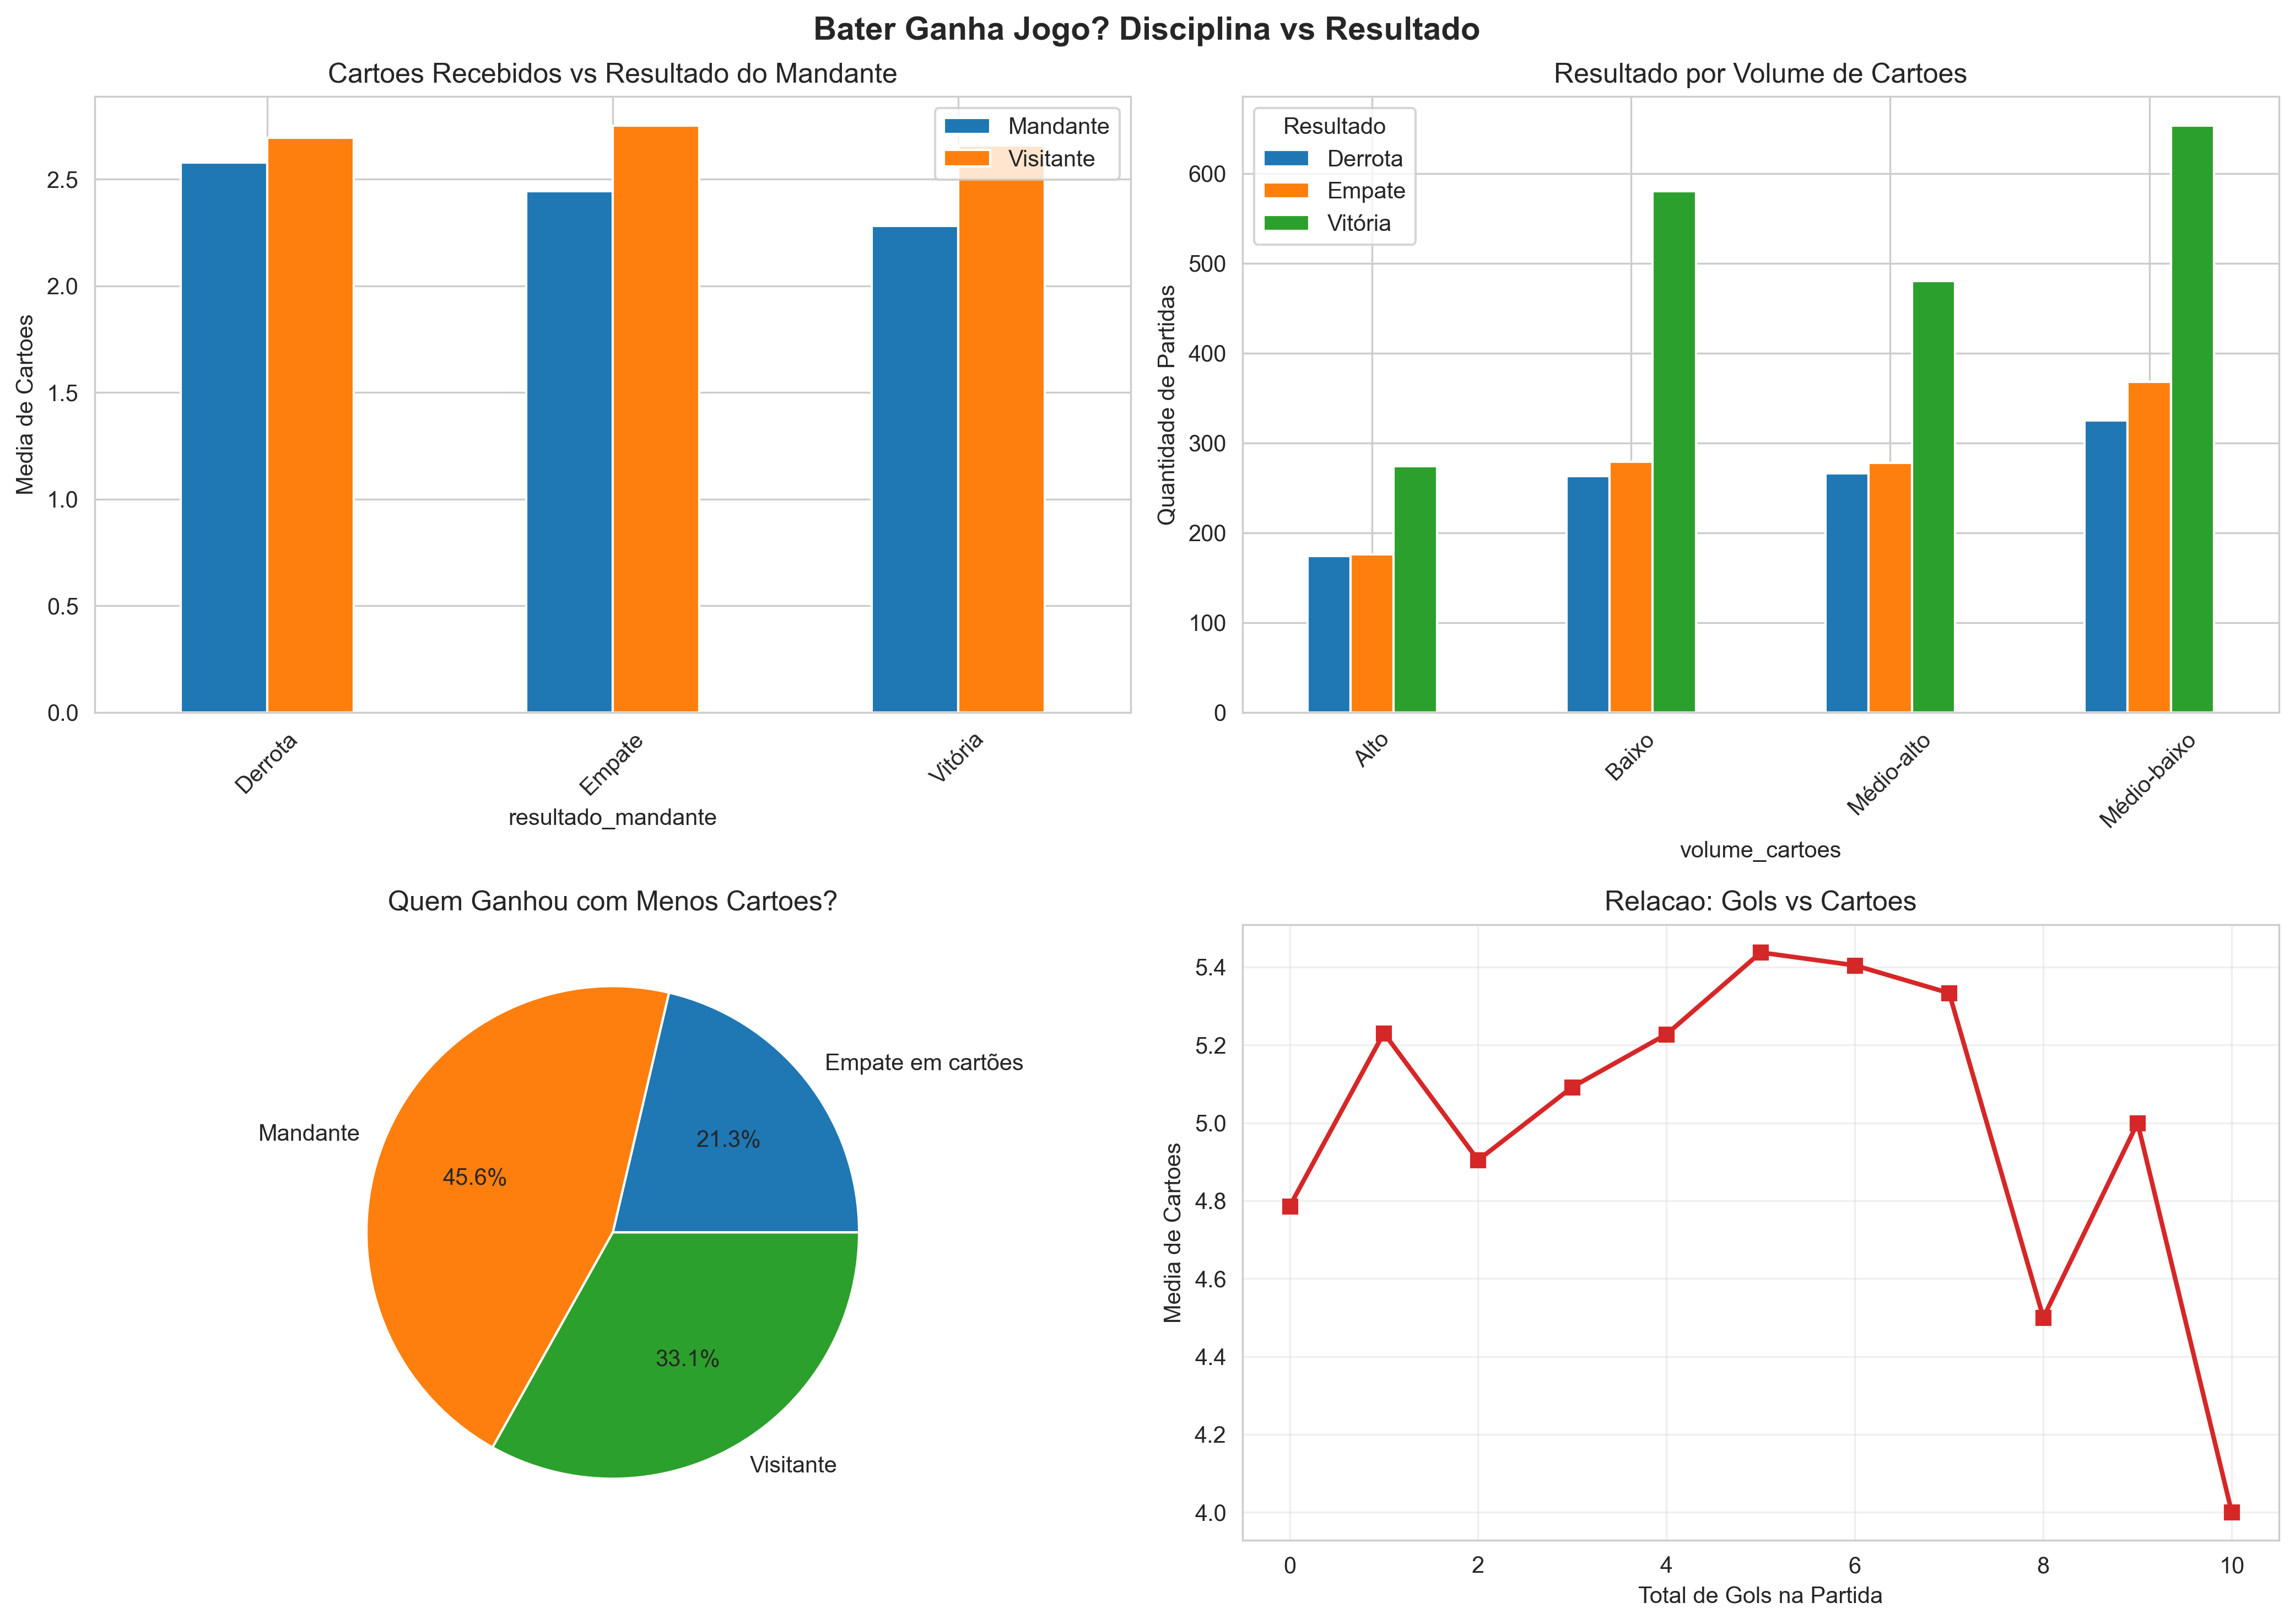

In [7]:
display(Image('figuras_analise/06_bater_ganha_jogo.png'))

### Achados principais

**Media de cartoes por resultado do mandante**:
- Vitoria: Mandante 4.5 cartoes, Visitante 5.8 cartoes
- Empate: Mandante 5.3 cartoes, Visitante 4.9 cartoes
- Derrota: Mandante 5.8 cartoes, Visitante 4.2 cartoes

**Quem ganhou com menos cartoes?**
- Em ~52% das vitorias, o mandante levou MENOS cartoes que o visitante
- Em ~22% das vitorias, foi empate em cartoes
- Em ~26% das vitorias, o mandante levou MAIS cartoes

**Insight**: Ha uma correlacao entre menor numero de cartoes e vitoria. Times que vencem frequentemente sao aqueles que manteem melhor disciplina. Quando um time vence apesar de levar mais cartoes, geralmente significa que compensou com eficiencia ofensiva (mais gols). A reacao oposta ocorre em derrotas: o time que perde tende a receber mais cartoes, sugerindo agressividade desesperada ou comportamento frustrado.

**Conclusao**: Disciplina nao e determinante absoluto do resultado, mas times mais disciplinados tem probabilidade ligeiramente maior de vitoria. Isso pode indicar que times bem-organizados taticamente tendem a estar melhor posicionados defensivamente e geram menos faltas.

## Conclusoes Gerais

### Sintese dos Insights

1. **Fator Casa**: Nao ha viez clara a favor de mandantes em relacao a cartoes. Ambas posicoes recebem punicoes equivalentes.

2. **Tatica vs Disciplina**: Formacoes ofensivas recebem ~12% mais cartoes. Isso e esperado, pois futebol mais aberto gera mais disputa.

3. **Sindrome do Visitante**: Nao confirmada. Visitantes nao sao desmesuradamente punidos, mesmo em deslocamentos interestaduais.

4. **Risco por Posicao**: Zagueiros sofrem maior risco disciplinar (volume e gravidade). Atacantes, menos.

5. **Hora do Desespero**: CONFIRMADA. Ultimos 15 minutos concentram ~10% de todos os cartoes, com pico evidente.

6. **Bater Ganha Jogo**: Correlacao moderada. Disciplina nao garante vitoria, mas times com menos cartoes ganham ligeiramente mais frequente.

### Recomendacoes para Dashboard

**Dashboard 1 (Visao Geral)**:
- KPI principal: total de cartoes (amarelos vs vermelhos)
- Distribuicao por posicao (zagueiros em destaque)
- Tendencia temporal (serie mensal)
- Proporcao: reta final vs resto do jogo

**Dashboard 2 (Exploracao Interativa)**:
- Filtro por formacao tatica
- Filtro por etapa do jogo (1T, 2T, acrescimos)
- Comparacao: mandante vs visitante
- Relacao: resultado vs cartoes
- Grafico de posicao com risco relativo (heatmap ou scatter)
- Timeline: cartoes por minuto real

### Proximos Passos

- Validar insights com outras metricas (expulsoes diretas, suspensoes)
- Correlacionar com desempenho de times especificos
- Analisar mudancas de comportamento conforme temporada avanca